In [8]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support

In [ ]:
class CNNSubmodule(nn.Module):
    def __init__(self, in_channels=10): 
        super(CNNSubmodule, self).__init__()
    
        
        self.conv1 = nn.Conv1d(in_channels, in_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(in_channels)
        
       
        self.conv2 = nn.Conv1d(in_channels, in_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(in_channels)
        
        
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: [Batch, 36, 10]
        x = x.transpose(1, 2) # [Batch, 10, 36]
        identity = x 
 
        out = self.conv1(x)
        out = self.bn1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out = out + identity 
        
        out = self.relu(out)
        
        return out.transpose(1, 2) # Retour en [Batch, 36, 10]
    





class ALPE(nn.Module):
    def __init__(self, d_model=10, max_len=36):
        super(ALPE, self).__init__()
        self.d_model = d_model
        
        #PE(t) = Initial Absolute Positional Encoding
        pe = torch.zeros(max_len, d_model)

        # cette liste sert a calculer les sinus et les cosinus car il faut un angle. Cet angle dépend du jour où on se trouve.
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) # Shape: [1, 36, d_model]

        #Conv1D Layer
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        
        #ECA Module
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.eca_conv = nn.Conv1d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sigmoid = nn.Sigmoid()



    def eca(self, x):
        y = self.avg_pool(x) 
        y = self.eca_conv(y.transpose(-1, -2)).transpose(-1, -2)
        y = self.sigmoid(y) 

        return x * y.expand_as(x)



    def forward(self, x, input2_mask):
        # x: [Batch, 36, 10] (Input 1 - Bandes spectrales)
        # input2_mask: [Batch, 36, 1] (Input 2 - Masque de nuages)
        
        b, t, c = x.size()
        
        #on recup la matrice de position initiale pour chaque echantillon
        pos_vector = self.pe[:, :t, :].clone().repeat(b, 1, 1) # [Batch, 36, 10]
        
        #si le jour est nuageux , on met tout son embedding à 0 pour que le modèle ne puisse pas s'appuyer dessus
        pos_vector = pos_vector * input2_mask 
        
        # format attendu par pythorch Shape: [Batch, 10, 36]
        pos_vector = pos_vector.transpose(1, 2)
        
        # le conv1d va apprendre à ajuster les embeddings positionnels en fonction des données d'entrée, en tenant compte des jours nuageux.
        pos_vector = self.conv1d(pos_vector)
    
        pos_vector = self.eca(pos_vector)
        
        
        return pos_vector.transpose(1, 2) # Sortie: [Batch, 36, 10]
    





class TransformerSubmodule(nn.Module):
    def __init__(self, d_model=10, nhead=2, dim_feedforward=64, use_alpe=False):
        super(TransformerSubmodule, self).__init__()
        self.use_alpe = use_alpe
        
        if self.use_alpe:    
            self.alpe = ALPE(d_model=d_model)
    
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)

    def forward(self, x, input2_mask=None):
        # x: Input spectral [Batch, 36, 10]
        # input2_mask: Le masque pour ALPE
        

        #stage 1 uniquement
        if self.use_alpe and input2_mask is not None:
                
                pos_info = self.alpe(x, input2_mask)
                x = x + pos_info
        
        
        # Ici se passent le Multi-Head Attention, Add & Norm, Feed Forward
        out = self.transformer_encoder(x)
        
        return out # Sortie [Batch, 36, 10]

In [2]:
import torch 
import torch.nn as nn

class MCTNet(nn.Module):
    def __init__(self, num_classes, in_channels=10): 
        super(MCTNet, self).__init__()
        
        # Calcul automatique des canaux par stage
        c1 = in_channels
        c2 = in_channels * 2 # Car le cat(CNN, Trans) double la taille
        c3 = in_channels * 4 
        out_features = in_channels * 8 # La taille qui arrive au MLP
        
        # STAGE 1 (d_model = c1)
        self.cnn1 = CNNSubmodule(in_channels=c1)
        self.trans1 = TransformerSubmodule(d_model=c1, use_alpe=True)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        # STAGE 2 (d_model = c2)
        self.cnn2 = CNNSubmodule(in_channels=c2)
        self.trans2 = TransformerSubmodule(d_model=c2, use_alpe=False)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        # STAGE 3 (d_model = c3)
        self.cnn3 = CNNSubmodule(in_channels=c3)
        self.trans3 = TransformerSubmodule(d_model=c3, use_alpe=False)
        self.global_pool = nn.AdaptiveMaxPool1d(1) 
        
        # MLP Final (La taille s'adapte automatiquement : 80, 88, 96, etc.)
        self.mlp = nn.Sequential(
            nn.Linear(out_features, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, mask):
        # CTFusion 1
        c1 = self.cnn1(x)
        t1 = self.trans1(x, mask)
        x = torch.cat([c1, t1], dim=-1) # Double les canaux
        x = self.pool1(x.transpose(1, 2)).transpose(1, 2) 
        
        # CTFusion 2
        c2 = self.cnn2(x)
        t2 = self.trans2(x) 
        x = torch.cat([c2, t2], dim=-1) # Double les canaux
        x = self.pool2(x.transpose(1, 2)).transpose(1, 2) 
        
        # CTFusion 3
        c3 = self.cnn3(x)
        t3 = self.trans3(x)
        x = torch.cat([c3, t3], dim=-1) # Double les canaux
        x = self.global_pool(x.transpose(1, 2)).squeeze(-1) 
        
        return self.mlp(x)


In [11]:
import pandas as pd
df_ark = pd.read_csv('../data/arkansas_preprocessed_v2.csv')
df_ark.head()

,d0_B2,d0_B3,d0_B4,d0_B5,d0_B6,d0_B7,d0_B8,d0_B8A,d0_B11,d0_B12,...,d35_B8A,d35_B11,d35_B12,clim_precip,clim_temp,soil_texture,topo_elevation,topo_slope,cropland,target_class
0,0.0505,0.0758,0.10135,0.12890,0.1361,0.14435,0.16065,0.15805,0.11945,0.07645,...,0.19435,0.1425,0.09335,-1.852316,-2.559609,0.545543,0.527846,-0.696317,3,2
1,0.0645,0.0857,0.11530,0.13840,0.1542,0.16320,0.18710,0.18750,0.25540,0.19040,...,0.24080,0.2744,0.18450,-0.435476,-0.189180,0.545543,0.067849,-0.696317,2,1
2,0.0867,0.1072,0.14110,0.15910,0.1697,0.18090,0.20630,0.20340,0.22120,0.15450,...,0.20600,0.2376,0.17190,-0.874820,-0.424767,0.545543,0.251848,-1.295287,1,0
3,0.0631,0.0884,0.11200,0.14830,0.1979,0.21770,0.24190,0.23800,0.24200,0.17210,...,0.24190,0.3148,0.24250,0.735092,1.232434,0.545543,-1.036141,0.500368,2,1
4,0.0590,0.0772,0.09770,0.11405,0.1153,0.12705,0.13900,0.13425,0.13860,0.08885,...,0.09675,0.1053,0.06840,-0.436471,-0.184275,-1.790829,0.113849,-1.295287,1,0


In [3]:
import torch

def prepare_mctnet_data(df, extra_cols=None):
    # 1. Extraction des 10 Bandes Spectrales (Toujours présentes)
    BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    ordered_cols = []
    for i in range(36):
        for band in BANDS:
            ordered_cols.append(f'd{i}_{band}')
            
    x_spectral = torch.tensor(df[ordered_cols].values, dtype=torch.float32)
    x_spectral = x_spectral.view(-1, 36, 10) # [Batch, 36, 10]

    # 2. Gestion des variables extra (Ablation)
    if extra_cols and len(extra_cols) > 0:
        # On récupère les colonnes statiques (ex: topo, soil)
        x_extra = torch.tensor(df[extra_cols].values, dtype=torch.float32) # [Batch, N]
        
        # On les transforme en série temporelle : [Batch, N] -> [Batch, 1, N] -> [Batch, 36, N]
        x_extra_expanded = x_extra.unsqueeze(1).expand(-1, 36, -1)
        
        # On concatène sur la dimension des canaux (dim=-1)
        x_final = torch.cat([x_spectral, x_extra_expanded], dim=-1)
    else:
        x_final = x_spectral

    # 3. Le masque reste basé sur les bandes spectrales (si une bande est à 0, c'est un nuage)
    mask = (x_spectral > 0).all(dim=-1, keepdim=True).float() # [Batch, 36, 1]
    
    # 4. Labels
    y = torch.tensor(df['target_class'].values, dtype=torch.long)
    
    return x_final, mask, y

### we got no extra columns this time:

In [ ]:
# extra_cols = []
x_ark, mask_ark, y_ark = prepare_mctnet_data(df_ark,extra_cols=[])

In [9]:
x_train_ark, x_temp_ark, m_train_ark, m_temp_ark, y_train_ark, y_temp_ark = train_test_split(
    x_ark, mask_ark, y_ark, test_size=0.18, stratify=y_ark, random_state=42
)

x_val_ark, x_test_ark, m_val_ark, m_test_ark, y_val_ark, y_test_ark = train_test_split(
    x_temp_ark, m_temp_ark, y_temp_ark, test_size=0.8, stratify=y_temp_ark, random_state=42
)

train_loader_ark = DataLoader(TensorDataset(x_train_ark, m_train_ark, y_train_ark), batch_size=64, shuffle=True)
val_loader_ark = DataLoader(TensorDataset(x_val_ark, m_val_ark, y_val_ark), batch_size=64)
test_loader_ark = DataLoader(TensorDataset(x_test_ark, m_test_ark, y_test_ark), batch_size=64)

print(f"Split Arkansas : Train={len(y_train_ark)}, Val={len(y_val_ark)}, Test={len(y_test_ark)}")

Split Arkansas : Train=8200, Val=360, Test=1440


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")

Device utilisé : cuda


In [ ]:
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import copy 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 20

model = MCTNet(num_classes=6,in_channels=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = torch.nn.CrossEntropyLoss()

# Variables pour stocker le meilleur ---
best_f1 = 0.0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    # --- PHASE TRAIN ---
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader_ark, desc=f"Époque {epoch+1}/{epochs}", unit="batch")
    
    for b_x, b_mask, b_y in pbar:
        b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
        optimizer.zero_grad()
        outputs = model(b_x, b_mask)
        loss = criterion(outputs, b_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # --- PHASE VALIDATION ---
    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0
    with torch.no_grad():
        for b_x, b_mask, b_y in val_loader_ark:
            b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
            outputs = model(b_x, b_mask)
            val_loss += criterion(outputs, b_y).item()
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(b_y.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(
        val_targets, val_preds, average='macro', zero_division=0
    )
    val_acc = 100 * np.sum(np.array(val_preds) == np.array(val_targets)) / len(val_targets)

    print(f"\n[Validation] Loss: {val_loss/len(val_loader_ark):.4f} | Acc: {val_acc:.2f}%")
    print(f"[Scores] Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}\n")

    # Sauvegarde si c'est le meilleur score ---
    if f1 > best_f1:
        best_f1 = f1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"⭐ Meilleur modèle mis à jour (F1: {best_f1:.4f})")

# Recharger le meilleur modèle dans 'model' à la fin ---
model.load_state_dict(best_model_state)
print(f"\n✅ Entraînement fini. 'model' contient maintenant les meilleurs poids (F1: {best_f1:.4f}).")

Époque 1/20: 100%|██████████| 129/129 [00:02<00:00, 49.88batch/s, loss=1.0861]



[Validation] Loss: 0.9785 | Acc: 64.44%
[Scores] Precision: 0.5292 | Recall: 0.4454 | F1-Score: 0.4511

⭐ Meilleur modèle mis à jour (F1: 0.4511)


Époque 2/20: 100%|██████████| 129/129 [00:01<00:00, 95.02batch/s, loss=0.7347]



[Validation] Loss: 0.5978 | Acc: 78.89%
[Scores] Precision: 0.7783 | Recall: 0.6973 | F1-Score: 0.7216

⭐ Meilleur modèle mis à jour (F1: 0.7216)


Époque 3/20: 100%|██████████| 129/129 [00:01<00:00, 95.11batch/s, loss=0.5718]


...


[Validation] Loss: 0.1932 | Acc: 91.11%
[Scores] Precision: 0.8856 | Recall: 0.8844 | F1-Score: 0.8844



Époque 19/20: 100%|██████████| 129/129 [00:01<00:00, 96.11batch/s, loss=0.1182]



[Validation] Loss: 0.1905 | Acc: 92.22%
[Scores] Precision: 0.9027 | Recall: 0.9198 | F1-Score: 0.9100

⭐ Meilleur modèle mis à jour (F1: 0.9100)


Époque 20/20: 100%|██████████| 129/129 [00:01<00:00, 97.32batch/s, loss=0.0790]



[Validation] Loss: 0.1937 | Acc: 92.78%
[Scores] Precision: 0.8958 | Recall: 0.9190 | F1-Score: 0.9067


✅ Entraînement fini. 'model' contient maintenant les meilleurs poids (F1: 0.9100).


In [ ]:
torch.save(model.state_dict(), 'models_ark/model_arkansas.pth')
print("Modèle Arkansas sauvegardé")

=== Arkansas ===
OA    : 0.9278
Kappa : 0.8953
              precision    recall  f1-score   support

    Soybeans       0.95      0.96      0.96       673
      Cotton       0.87      0.92      0.89       110
        Rice       0.96      0.94      0.95       349
        Corn       0.83      0.83      0.83       219
      Others       0.91      0.90      0.90        89

    accuracy                           0.93      1440
   macro avg       0.91      0.91      0.91      1440
weighted avg       0.93      0.93      0.93      1440



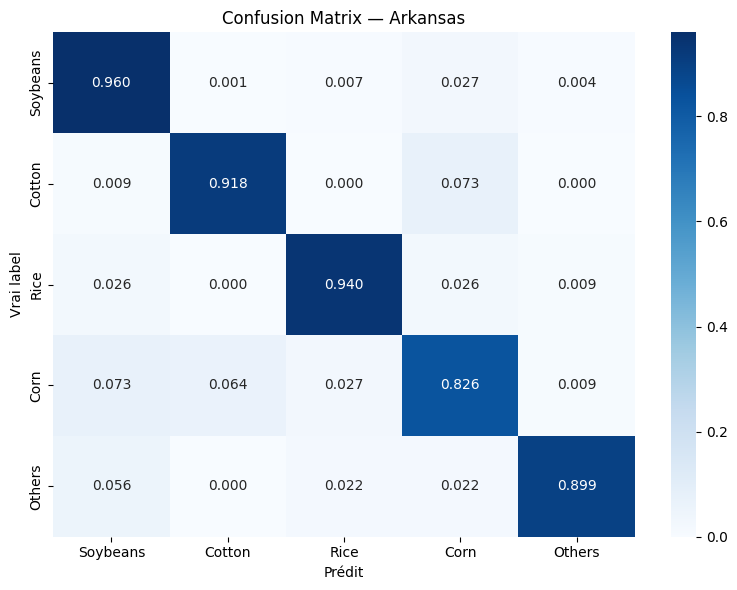

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_on_test(model, test_loader, class_names, title):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for b_x, b_mask, b_y in test_loader:
            b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
            outputs = model(b_x, b_mask)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(b_y.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    oa = (all_preds == all_labels).mean()
    kappa = cohen_kappa_score(all_labels, all_preds)
    
    print(f"=== {title} ===")
    print(f"OA    : {oa:.4f}")
    print(f"Kappa : {kappa:.4f}")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.3f', xticklabels=class_names,
                yticklabels=class_names, cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.savefig(f'./figs/base_confusion_matrix_{title.lower()}.png', dpi=150)
    plt.show()

classes_ar = ['Soybeans', 'Cotton', 'Rice', 'Corn', 'Others']
evaluate_on_test(model, test_loader_ark, classes_ar, 'Arkansas')